# Notebook 03 - Transformer Model Training & Evaluation (NSL-KDD)

**Pipeline stages covered:**
1. Load pre-processed splits from Notebook 02
2. Build PyTorch DataLoaders
3. Instantiate Transformer classifier
4. Training loop with live progress
5. Loss & accuracy curves
6. Evaluation: Accuracy · Precision · Recall · F1-Score
7. Confusion matrix (raw + normalized)
8. Per-class metrics bar chart & radar chart
9. ROC curves (one-vs-rest)
10. Save model + all artifacts to `model/`

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import torch
import joblib
from sklearn.metrics import classification_report, confusion_matrix

from utils.model_utils import (
    TransformerClassifier,
    make_dataloaders,
    train_model,
    eval_epoch,
    compute_metrics,
    save_model,
)
from utils.visualization import (
    plot_training_history,
    plot_confusion_matrix,
    plot_evaluation_metrics,
    plot_metrics_radar,
    plot_roc_curves,
)

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f'✓ Imports OK  |  Device: {device}')

✓ Imports OK  |  Device: cpu


In [2]:
# ── Configuration ──────────────────────────────────────────────────────────
DATA_DIR   = '../../data/processed-nslkdd'
MODEL_DIR  = '../../model/nsl-kdd'

# Transformer hyperparameters
D_MODEL        = 128
N_HEADS        = 4
N_LAYERS       = 2
DIM_FEEDFORWARD= 256
DROPOUT        = 0.1

# Training hyperparameters
N_EPOCHS       = 10
BATCH_SIZE     = 512
LEARNING_RATE  = 1e-3
RANDOM_STATE   = 42

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
os.makedirs(MODEL_DIR, exist_ok=True)
print('Configuration set.')

Configuration set.


## 1 · Load Pre-processed Splits

In [3]:
with open(f'{DATA_DIR}/metadata.json') as f:
    meta = json.load(f)

class_names       = meta['class_names']
selected_features = meta['selected_features']
n_classes         = meta['n_classes']
n_features        = meta['n_features']

X_train = np.load(f'{DATA_DIR}/X_train_sc.npy')
X_test  = np.load(f'{DATA_DIR}/X_test_sc.npy')
y_train = np.load(f'{DATA_DIR}/y_train_enc.npy')
y_test  = np.load(f'{DATA_DIR}/y_test_enc.npy')

y_train_raw = pd.read_json(f'{DATA_DIR}/y_train_raw.json', typ='series')
y_test_raw  = pd.read_json(f'{DATA_DIR}/y_test_raw.json',  typ='series')

scaler        = joblib.load(f'{MODEL_DIR}/scaler.pkl')
label_encoder = joblib.load(f'{MODEL_DIR}/label_encoder.pkl')

print(f'Classes ({n_classes}): {class_names}')
print(f'Selected features ({n_features}): {selected_features}')
print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_test : {X_test.shape}   y_test : {y_test.shape}')

Classes (2): ['anomaly', 'normal']
Selected features (20): ['flag_SF', 'same_srv_rate', 'dst_host_srv_count', 'diff_srv_rate', 'dst_host_same_srv_rate', 'count', 'logged_in', 'dst_host_srv_serror_rate', 'protocol_type_icmp', 'dst_host_serror_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'flag_S0', 'srv_serror_rate', 'service_private', 'service_http', 'dst_host_srv_diff_host_rate', 'dst_host_count', 'rerror_rate', 'dst_host_rerror_rate']
X_train: (125973, 20)  y_train: (125973,)
X_test : (22544, 20)   y_test : (22544,)


## 2 · Build DataLoaders

In [4]:
train_loader, test_loader = make_dataloaders(
    X_train, y_train,
    X_test,  y_test,
    batch_size=BATCH_SIZE,
)
print(f'Train batches: {len(train_loader)}  |  Test batches: {len(test_loader)}')

Train batches: 247  |  Test batches: 45


## 3 · Instantiate Transformer Classifier

In [5]:
model = TransformerClassifier(
    n_features=n_features,
    n_classes=n_classes,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    dropout=DROPOUT,
)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTrainable parameters: {total_params:,}')

TransformerClassifier(
  (input_proj): Sequential(
    (0): Linear(in_features=20, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (classifier): Sequential(
    (0): Dropout(p=0.1, inplace=False)
    (1): Linear(in_features=128, out_features

## 4 · Training

In [6]:
history = train_model(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    n_epochs=N_EPOCHS,
    lr=LEARNING_RATE,
    device=device,
    verbose=True,
)

Epoch   1/10 │ Train Loss: 0.0784  Acc: 0.9744 │ Val Loss: 1.0687  Acc: 0.7323 │ LR: 9.76e-04
Epoch   2/10 │ Train Loss: 0.0539  Acc: 0.9807 │ Val Loss: 1.1988  Acc: 0.7476 │ LR: 9.05e-04
Epoch   3/10 │ Train Loss: 0.0465  Acc: 0.9832 │ Val Loss: 1.3378  Acc: 0.7538 │ LR: 7.94e-04
Epoch   4/10 │ Train Loss: 0.0405  Acc: 0.9849 │ Val Loss: 1.2886  Acc: 0.7333 │ LR: 6.55e-04
Epoch   5/10 │ Train Loss: 0.0348  Acc: 0.9871 │ Val Loss: 1.1125  Acc: 0.7561 │ LR: 5.00e-04
Epoch   6/10 │ Train Loss: 0.0324  Acc: 0.9880 │ Val Loss: 1.2130  Acc: 0.7459 │ LR: 3.45e-04
Epoch   7/10 │ Train Loss: 0.0274  Acc: 0.9892 │ Val Loss: 1.3849  Acc: 0.7639 │ LR: 2.06e-04
Epoch   8/10 │ Train Loss: 0.0256  Acc: 0.9898 │ Val Loss: 1.3586  Acc: 0.7740 │ LR: 9.55e-05
Epoch   9/10 │ Train Loss: 0.0236  Acc: 0.9906 │ Val Loss: 1.4433  Acc: 0.7663 │ LR: 2.45e-05
Epoch  10/10 │ Train Loss: 0.0219  Acc: 0.9913 │ Val Loss: 1.4270  Acc: 0.7670 │ LR: 0.00e+00


## 5 · Training History

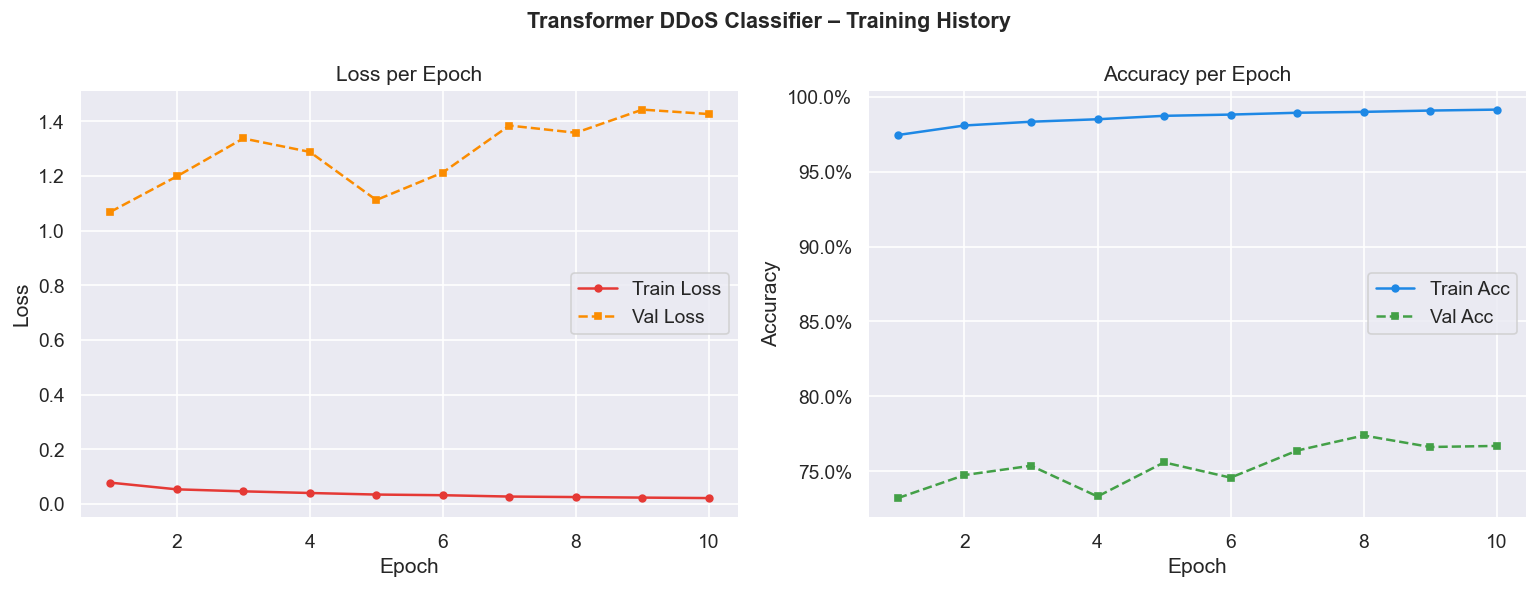

Best train acc : 0.9913
Best val acc   : 0.7740
Best val loss  : 1.0687


In [7]:
fig = plot_training_history(history, title='Transformer DDoS Classifier – Training History')
fig.savefig(f'{DATA_DIR}/fig_12_training_history.png', dpi=120, bbox_inches='tight')
plt.show()

best_train_acc = max(history['train_acc'])
best_val_acc   = max(history['val_acc'])
best_val_loss  = min(history['val_loss'])
print(f'Best train acc : {best_train_acc:.4f}')
print(f'Best val acc   : {best_val_acc:.4f}')
print(f'Best val loss  : {best_val_loss:.4f}')

## 6 · Final Evaluation on Test Set

In [8]:
import torch.nn as nn

criterion = nn.CrossEntropyLoss()
test_loss, test_acc, y_pred_idx, y_true_idx, y_probs = eval_epoch(
    model, test_loader, criterion, device
)

print(f'Test Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)')

Test Loss     : 1.4270
Test Accuracy : 0.7670  (76.70%)


In [9]:
# Full classification report
metrics = compute_metrics(y_true_idx, y_pred_idx, class_names)

print('=== Classification Report ===')
print(classification_report(
    y_true_idx, y_pred_idx,
    target_names=class_names,
    digits=4,
    zero_division=0,
))

=== Classification Report ===
              precision    recall  f1-score   support

     anomaly     0.9614    0.6154    0.7505     12833
      normal     0.6556    0.9674    0.7815      9711

    accuracy                         0.7670     22544
   macro avg     0.8085    0.7914    0.7660     22544
weighted avg     0.8297    0.7670    0.7639     22544



## 7 · Confusion Matrix

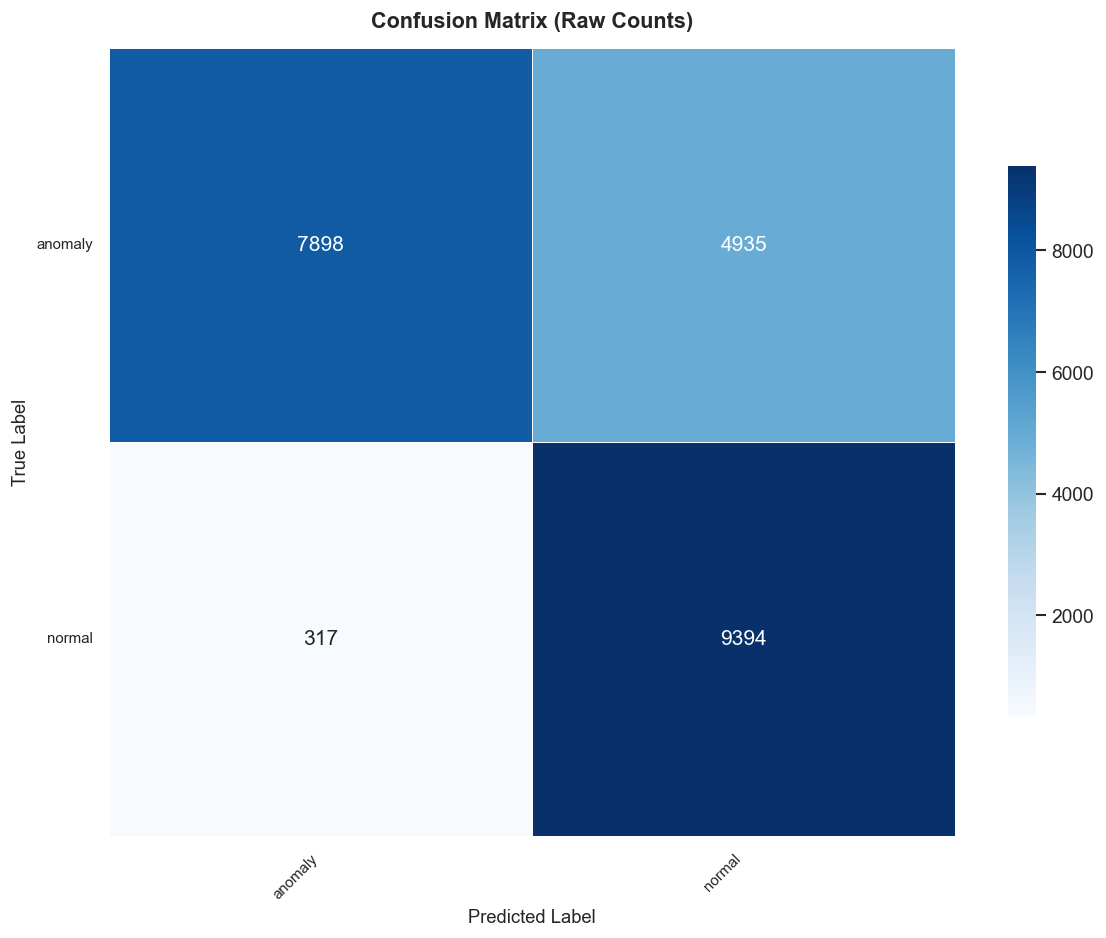

In [10]:
cm = metrics['confusion_matrix']

# Raw counts
fig = plot_confusion_matrix(cm, class_names,
                             title='Confusion Matrix (Raw Counts)',
                             normalize=False)
fig.savefig(f'{DATA_DIR}/fig_13_cm_raw.png', dpi=120, bbox_inches='tight')
plt.show()

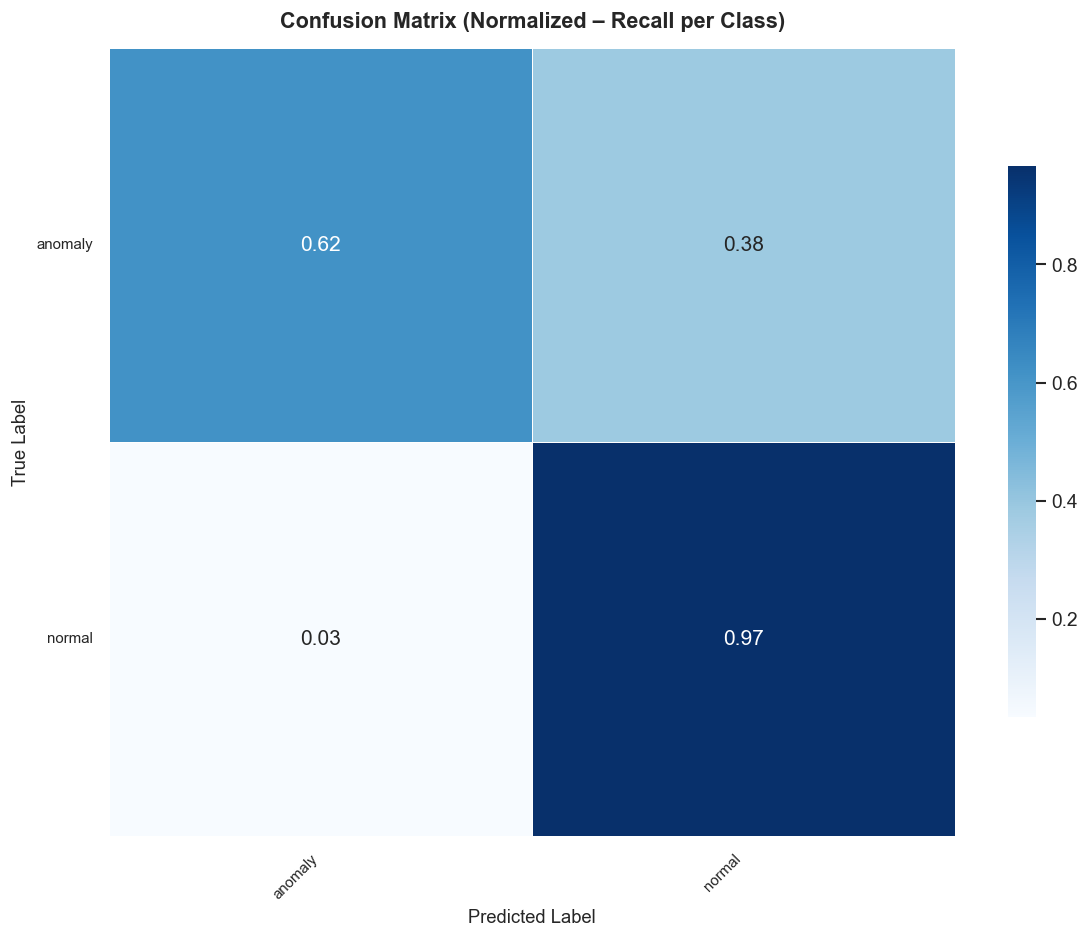

In [11]:
# Normalized (recall per class)
fig = plot_confusion_matrix(cm, class_names,
                             title='Confusion Matrix (Normalized – Recall per Class)',
                             normalize=True)
fig.savefig(f'{DATA_DIR}/fig_14_cm_normalized.png', dpi=120, bbox_inches='tight')
plt.show()

## 8 · Evaluation Metrics – Bar Chart & Radar Chart

In [12]:
# Summary table
skip_keys = {'accuracy', 'macro avg', 'weighted avg', 'confusion_matrix'}
metrics_table = {
    cls: {k: round(v, 4) for k, v in vals.items() if k != 'support'}
    for cls, vals in metrics.items()
    if cls not in skip_keys
}
metrics_table['accuracy'] = round(metrics['accuracy'], 4)
metrics_table['macro avg']    = {k: round(v, 4) for k, v in metrics['macro avg'].items()    if k != 'support'}
metrics_table['weighted avg'] = {k: round(v, 4) for k, v in metrics['weighted avg'].items() if k != 'support'}

summary_df = pd.DataFrame(metrics_table).T
print('=== Metrics Summary ===')
display(summary_df.style.background_gradient(cmap='RdYlGn', axis=None, vmin=0, vmax=1))

=== Metrics Summary ===


,precision,recall,f1-score
anomaly,0.961400,0.615400,0.750500
normal,0.655600,0.967400,0.781500
accuracy,0.767000,0.767000,0.767000
macro avg,0.808500,0.791400,0.766000
weighted avg,0.829700,0.767000,0.763900


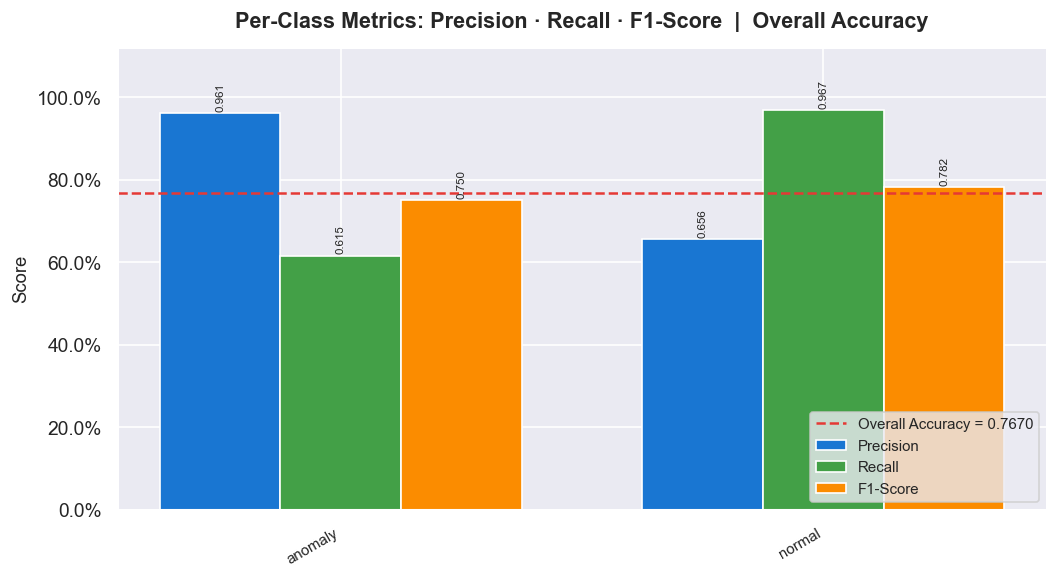

In [13]:
# Grouped bar chart: Precision, Recall, F1 per class
fig = plot_evaluation_metrics(
    metrics,
    title='Per-Class Metrics: Precision · Recall · F1-Score  |  Overall Accuracy'
)
fig.savefig(f'{DATA_DIR}/fig_15_metrics_bar.png', dpi=120, bbox_inches='tight')
plt.show()

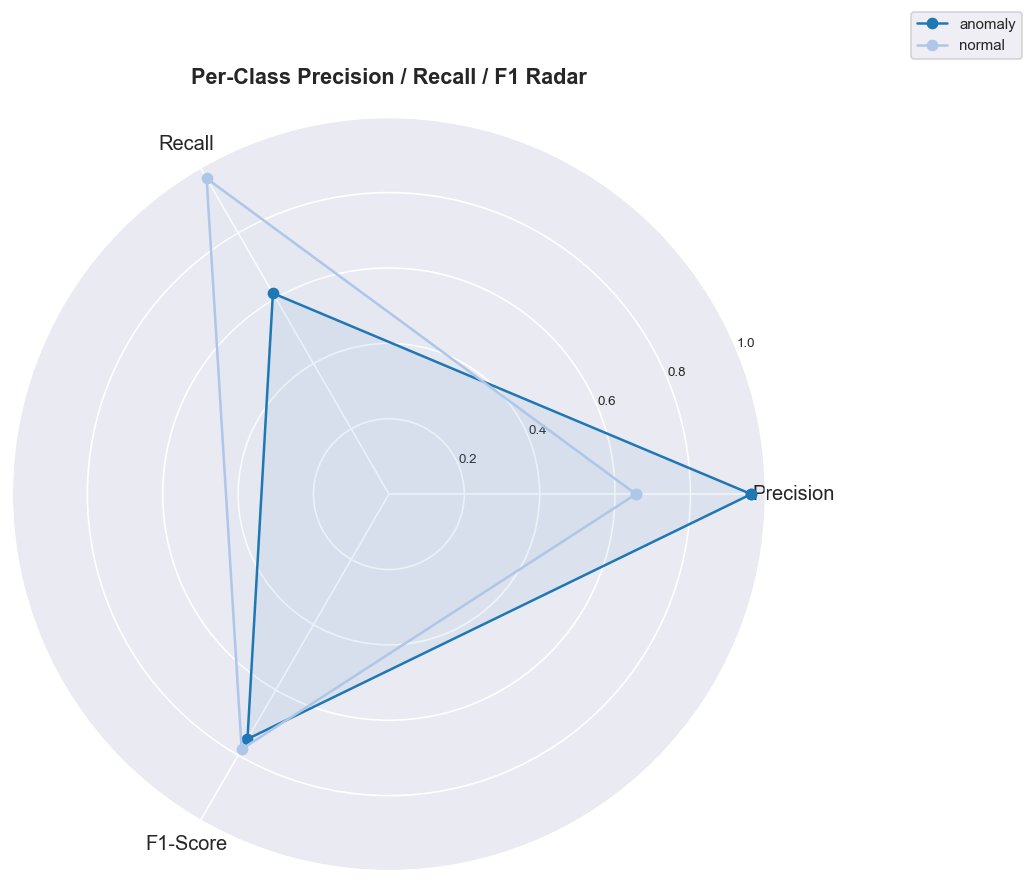

In [14]:
# Radar chart
fig = plot_metrics_radar(metrics, title='Per-Class Precision / Recall / F1 Radar')
fig.savefig(f'{DATA_DIR}/fig_16_metrics_radar.png', dpi=120, bbox_inches='tight')
plt.show()

## 9 · ROC Curves (One-vs-Rest)

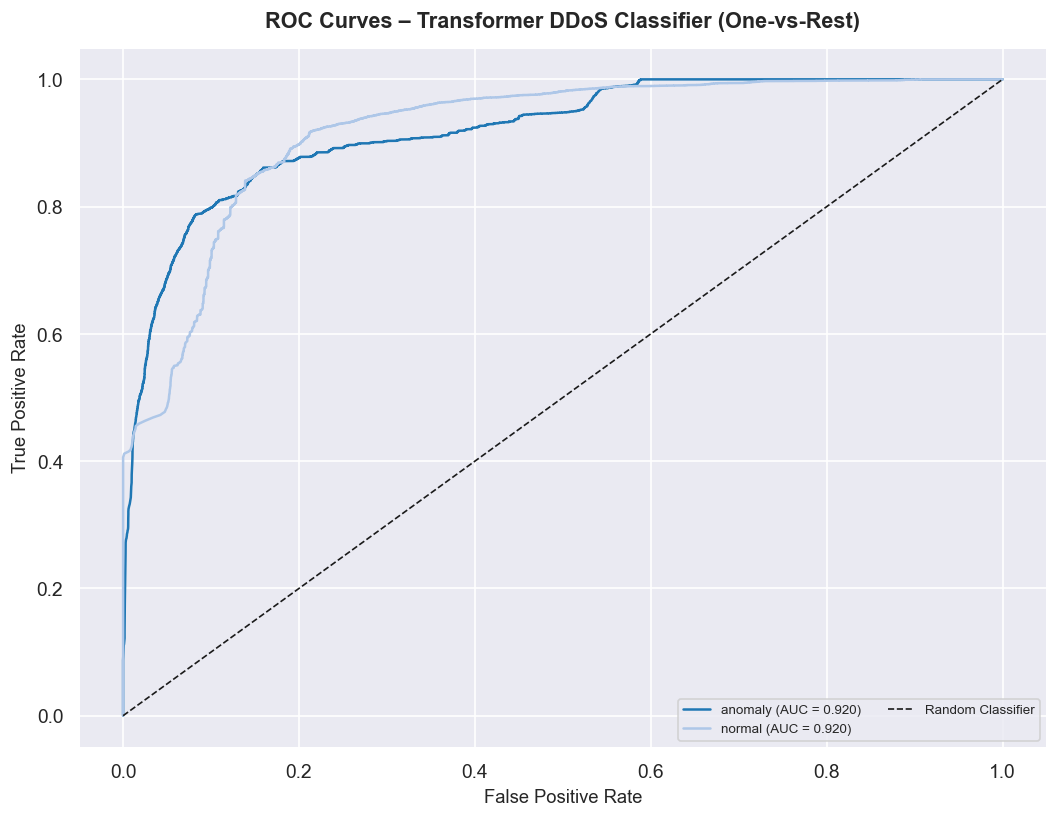

In [15]:
import numpy as np
# y_test is 1-D integer indices; plot_roc_curves needs one-hot
y_test_onehot = np.eye(n_classes)[y_test]

fig = plot_roc_curves(
    y_true_onehot=y_test_onehot,
    y_prob=y_probs,
    class_names=class_names,
    title='ROC Curves – Transformer DDoS Classifier (One-vs-Rest)',
)
fig.savefig(f'{DATA_DIR}/fig_17_roc_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## 10 · Per-Epoch Accuracy & Loss Summary Table

In [16]:
history_df = pd.DataFrame(history)
history_df.index = history_df.index + 1
history_df.index.name = 'Epoch'

# Highlight best epochs
display(
    history_df.style
    .highlight_max(subset=['train_acc', 'val_acc'], color='#C8E6C9')
    .highlight_min(subset=['train_loss', 'val_loss'], color='#BBDEFB')
    .format('{:.4f}')
)

,train_loss,val_loss,train_acc,val_acc
Epoch,,,,
1,0.0784,1.0687,0.9744,0.7323
2,0.0539,1.1988,0.9807,0.7476
3,0.0465,1.3378,0.9832,0.7538
4,0.0405,1.2886,0.9849,0.7333
5,0.0348,1.1125,0.9871,0.7561
6,0.0324,1.2130,0.9880,0.7459
7,0.0274,1.3849,0.9892,0.7639
8,0.0256,1.3586,0.9898,0.7740
9,0.0236,1.4433,0.9906,0.7663


## 11 · Save Model & Artifacts

In [17]:
save_model(
    model=model,
    scaler=scaler,
    label_encoder=label_encoder,
    selected_features=selected_features,
    model_dir=MODEL_DIR,
)

print('\n=== Saved Artifacts ===')
for root, dirs, files in os.walk(MODEL_DIR):
    for fname in files:
        fpath = os.path.join(root, fname)
        size  = os.path.getsize(fpath)
        print(f'  {fname:<35}  {size/1024:.1f} KB')

[model_utils] Model and artifacts saved to '../../model/nsl-kdd/'

=== Saved Artifacts ===
  label_encoder.pkl                    0.5 KB
  scaler.pkl                           5.4 KB
  selected_features.json               0.5 KB
  transformer_ddos.pt                  1123.7 KB


In [18]:
# Final summary
print('=' * 55)
print('  FINAL MODEL SUMMARY')
print('=' * 55)
print(f'  Architecture  : Transformer ({N_LAYERS} layers, {N_HEADS} heads, d={D_MODEL})')
print(f'  Input features: {n_features}')
print(f'  Output classes: {n_classes}')
print(f'  Epochs trained: {N_EPOCHS}')
print(f'  Test Accuracy : {test_acc*100:.2f}%')
print(f'  Macro F1      : {metrics["macro avg"]["f1-score"]*100:.2f}%')
print(f'  Weighted F1   : {metrics["weighted avg"]["f1-score"]*100:.2f}%')
print('=' * 55)

  FINAL MODEL SUMMARY
  Architecture  : Transformer (2 layers, 4 heads, d=128)
  Input features: 20
  Output classes: 2
  Epochs trained: 10
  Test Accuracy : 76.70%
  Macro F1      : 76.60%
  Weighted F1   : 76.39%


---
# Part II – Random Forest Multiclassifier

**Pipeline stages covered:**
1. Prepare integer labels from the one-hot-encoded arrays
2. Train a scikit-learn `RandomForestClassifier` on the same splits
3. Evaluation: Accuracy · Precision · Recall · F1-Score
4. Confusion matrix (raw + normalised)
5. Per-class metrics bar chart & radar chart
6. ROC curves (one-vs-rest)
7. Save RF model to `model/`

## RF-1 · Prepare Integer Labels

In [19]:
# Convert one-hot encoded labels back to integer class indices
if y_train.ndim == 2:
    y_train_int = np.argmax(y_train, axis=1)
    y_test_int  = np.argmax(y_test,  axis=1)
else:
    y_train_int = y_train
    y_test_int  = y_test

print(f'y_train_int shape : {y_train_int.shape}  unique classes: {np.unique(y_train_int).tolist()}')
print(f'y_test_int  shape : {y_test_int.shape}')

y_train_int shape : (125973,)  unique classes: [0, 1]
y_test_int  shape : (22544,)


## RF-2 · Train Random Forest

In [20]:
import time
from sklearn.ensemble import RandomForestClassifier

RF_N_ESTIMATORS     = 100
RF_MAX_DEPTH        = None   # grow full trees
RF_MIN_SAMPLES_LEAF = 2
RF_RANDOM_STATE     = RANDOM_STATE

rf_model = RandomForestClassifier(
    n_estimators=RF_N_ESTIMATORS,
    max_depth=RF_MAX_DEPTH,
    min_samples_leaf=RF_MIN_SAMPLES_LEAF,
    class_weight='balanced',
    random_state=RF_RANDOM_STATE,
    n_jobs=-1,           # use all CPU cores
    verbose=1,
)

t0 = time.time()
rf_model.fit(X_train, y_train_int)
elapsed = time.time() - t0
print(f'\nTraining complete in {elapsed:.1f}s')

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    1.3s



Training complete in 4.6s


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    4.5s finished


## RF-3 · Evaluate on Test Set

In [21]:
from sklearn.metrics import accuracy_score

rf_y_pred = rf_model.predict(X_test)
rf_y_prob = rf_model.predict_proba(X_test)   # shape (n_samples, n_classes)

rf_test_acc = accuracy_score(y_test_int, rf_y_pred)
print(f'Test Accuracy : {rf_test_acc:.4f}  ({rf_test_acc*100:.2f}%)')

Test Accuracy : 0.7494  (74.94%)


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished


In [22]:
# Full classification report
rf_metrics = compute_metrics(y_test_int, rf_y_pred, class_names)

print('=== Classification Report ===')
print(classification_report(
    y_test_int, rf_y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0,
))

=== Classification Report ===
              precision    recall  f1-score   support

     anomaly     0.9643    0.5813    0.7254     12833
      normal     0.6372    0.9716    0.7696      9711

    accuracy                         0.7494     22544
   macro avg     0.8007    0.7764    0.7475     22544
weighted avg     0.8234    0.7494    0.7444     22544



## RF-4 · Confusion Matrix

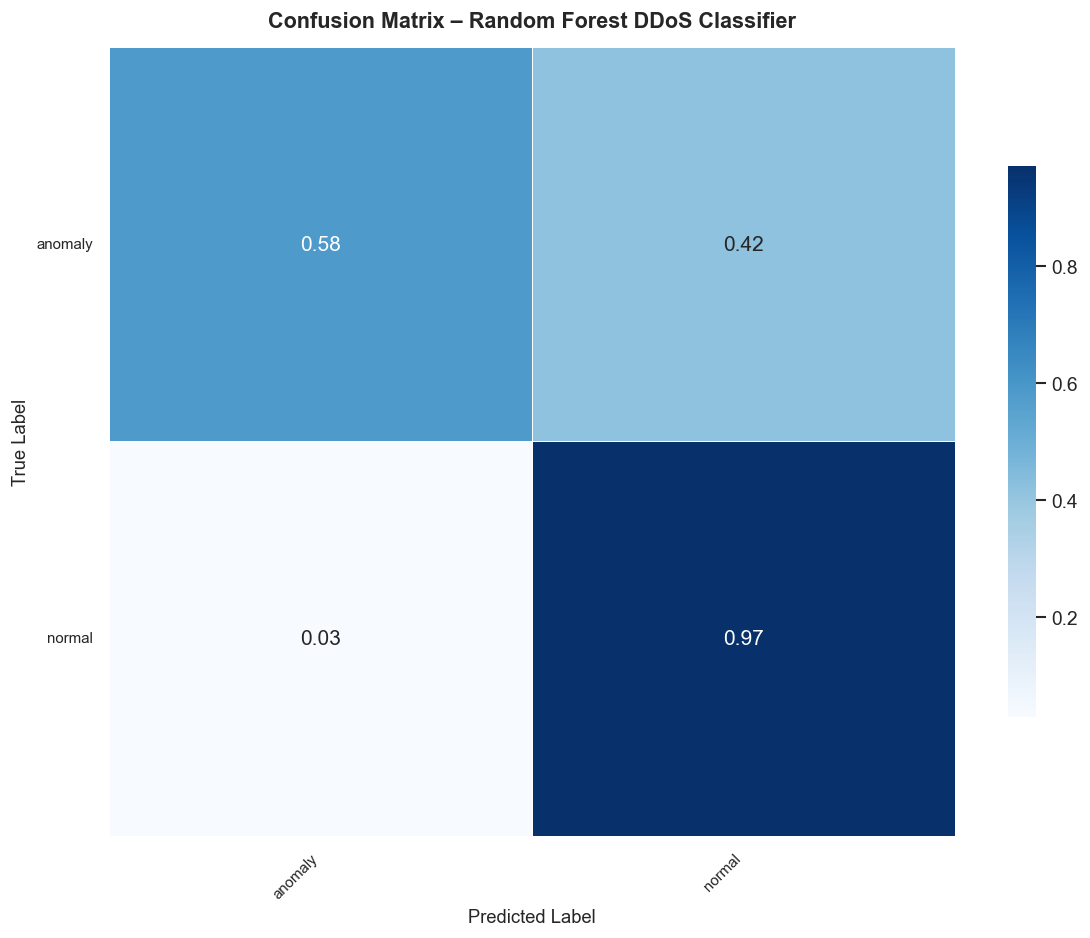

In [23]:
rf_cm = confusion_matrix(y_test_int, rf_y_pred)
fig = plot_confusion_matrix(rf_cm, class_names,
                             title='Confusion Matrix – Random Forest DDoS Classifier',
                             normalize=True)
fig.savefig(f'{DATA_DIR}/fig_rf_confusion_matrix_norm.png', dpi=120, bbox_inches='tight')
plt.show()

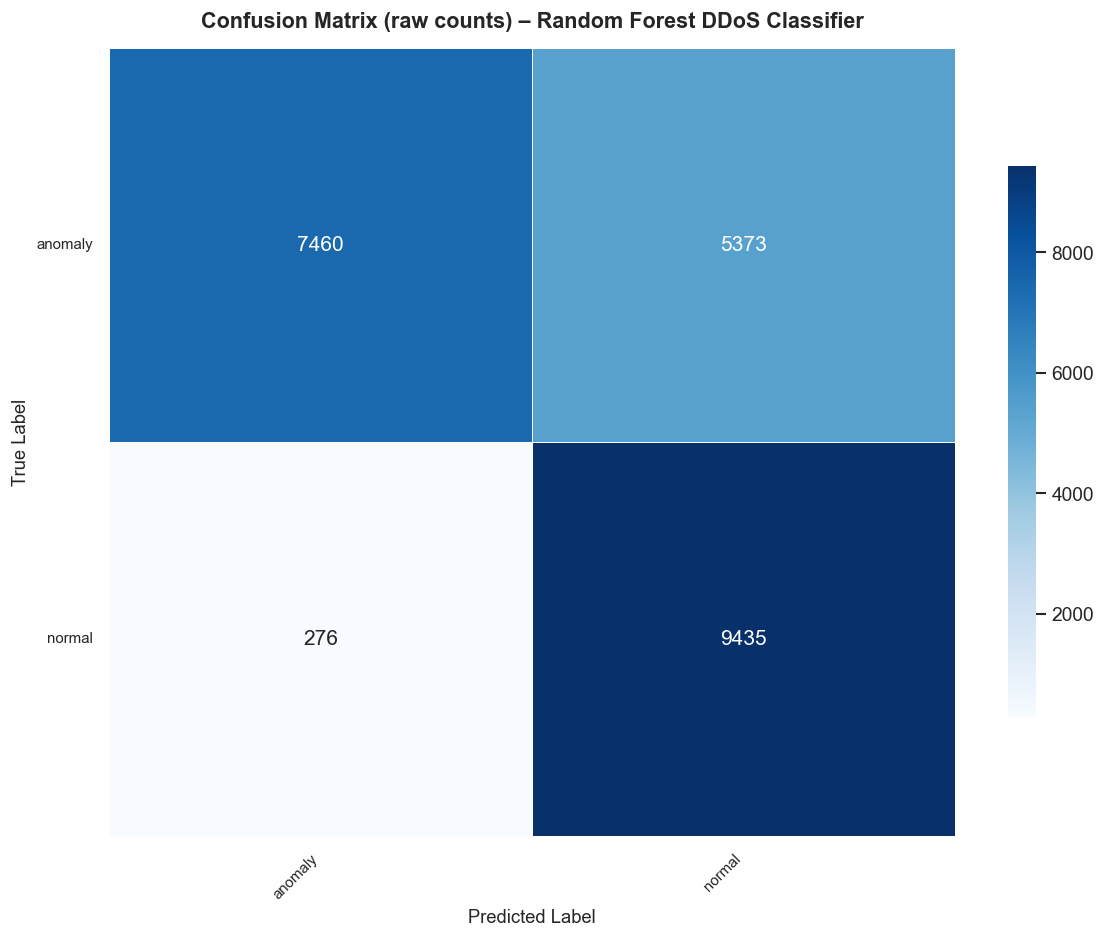

In [24]:
rf_cm = confusion_matrix(y_test_int, rf_y_pred)
fig = plot_confusion_matrix(rf_cm, class_names,
                             title='Confusion Matrix (raw counts) – Random Forest DDoS Classifier',
                             normalize=False)
fig.savefig(f'{DATA_DIR}/fig_rf_confusion_matrix_raw.png', dpi=120, bbox_inches='tight')
plt.show()

## RF-5 · Per-Class Metrics

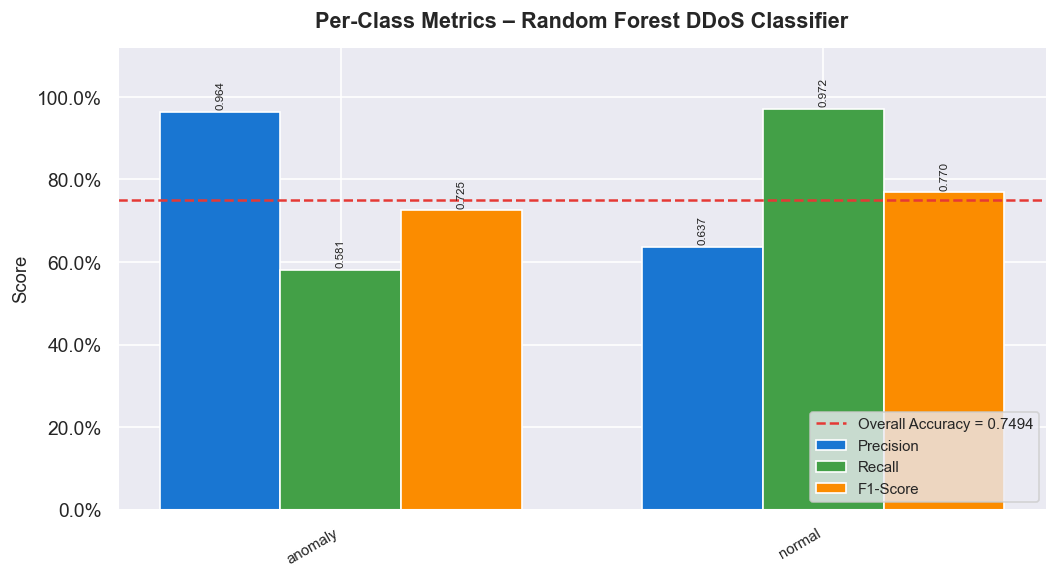

In [25]:
fig = plot_evaluation_metrics(
    metrics=rf_metrics,
    title='Per-Class Metrics – Random Forest DDoS Classifier',
)
fig.savefig(f'{DATA_DIR}/fig_rf_per_class_metrics.png', dpi=120, bbox_inches='tight')
plt.show()

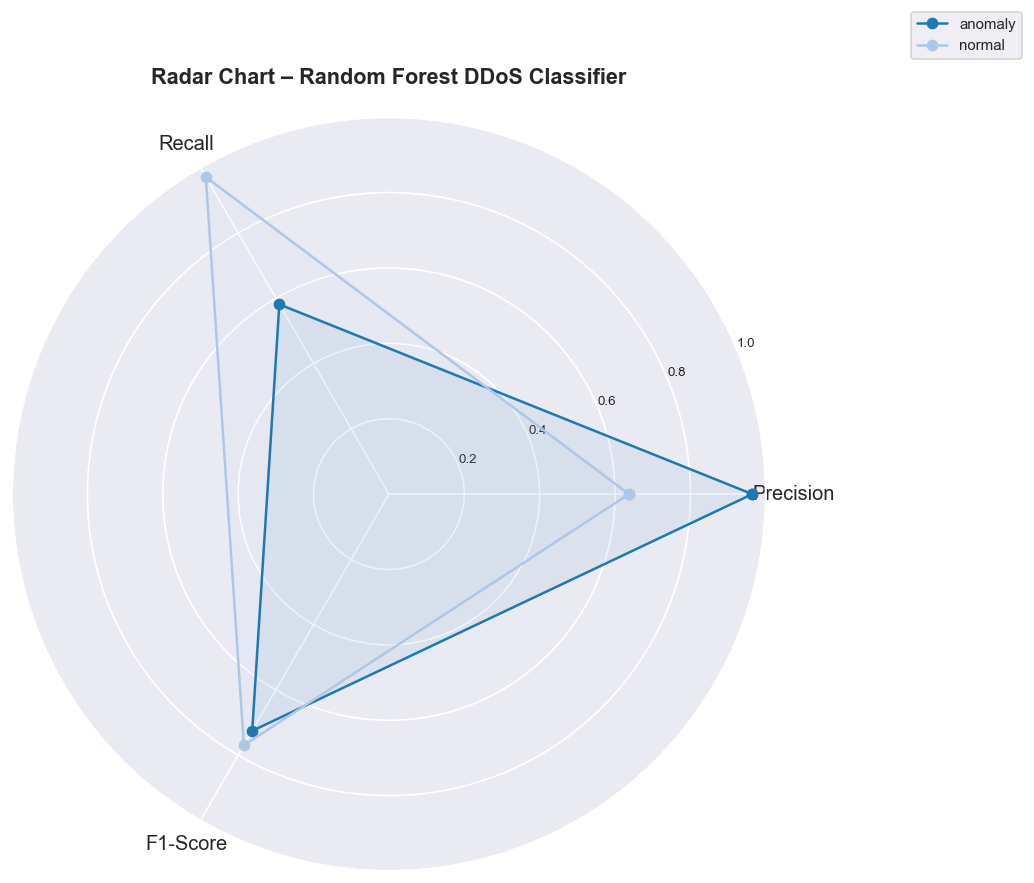

In [26]:
fig = plot_metrics_radar(
    metrics=rf_metrics,
    title='Radar Chart – Random Forest DDoS Classifier',
)
fig.savefig(f'{DATA_DIR}/fig_rf_radar.png', dpi=120, bbox_inches='tight')
plt.show()

## RF-6 · ROC Curves (One-vs-Rest)

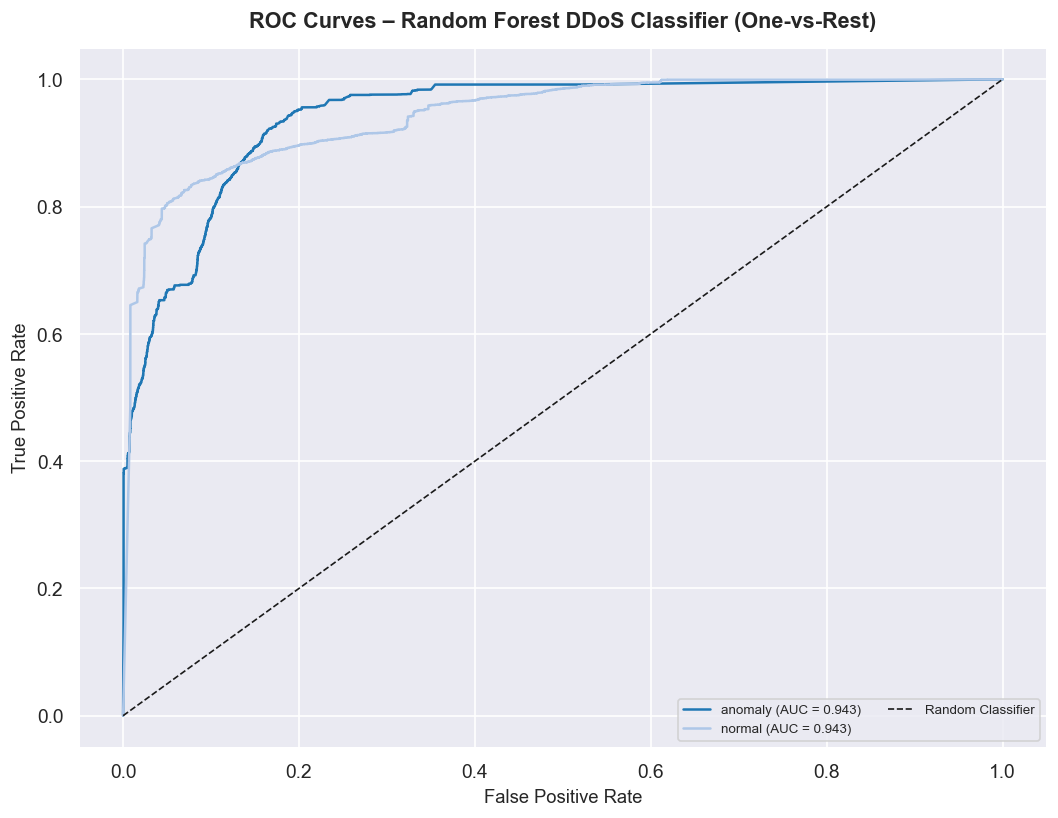

In [27]:
import numpy as np
# y_test is 1-D integer indices; plot_roc_curves needs one-hot
y_test_onehot = np.eye(n_classes)[y_test]

fig = plot_roc_curves(
    y_true_onehot=y_test_onehot,
    y_prob=rf_y_prob,
    class_names=class_names,
    title='ROC Curves – Random Forest DDoS Classifier (One-vs-Rest)',
)
fig.savefig(f'{DATA_DIR}/fig_rf_roc_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## RF-7 · Save Random Forest Model

In [28]:
import joblib, os

rf_model_path = os.path.join(MODEL_DIR, 'random_forest_ddos.pkl')
joblib.dump(rf_model, rf_model_path)
print(f'Random Forest model saved to: {rf_model_path}')
size_kb = os.path.getsize(rf_model_path) / 1024
print(f'File size: {size_kb:.1f} KB')

print('\n=== Saved Artifacts ===')
for root, dirs, files in os.walk(MODEL_DIR):
    for fname in sorted(files):
        fpath = os.path.join(root, fname)
        size  = os.path.getsize(fpath)
        print(f'  {fname:<40}  {size/1024:.1f} KB')

Random Forest model saved to: ../../model/nsl-kdd\random_forest_ddos.pkl
File size: 10999.4 KB

=== Saved Artifacts ===
  label_encoder.pkl                         0.5 KB
  random_forest_ddos.pkl                    10999.4 KB
  scaler.pkl                                5.4 KB
  selected_features.json                    0.5 KB
  transformer_ddos.pt                       1123.7 KB


In [29]:
# Final RF summary
print('=' * 55)
print('  FINAL RANDOM FOREST MODEL SUMMARY')
print('=' * 55)
print(f'  Algorithm     : RandomForestClassifier')
print(f'  N estimators  : {RF_N_ESTIMATORS}')
print(f'  Max depth     : {RF_MAX_DEPTH}')
print(f'  Input features: {n_features}')
print(f'  Output classes: {n_classes}')
print(f'  Test Accuracy : {rf_test_acc*100:.2f}%')
print(f'  Macro F1      : {rf_metrics["macro avg"]["f1-score"]*100:.2f}%')
print(f'  Weighted F1   : {rf_metrics["weighted avg"]["f1-score"]*100:.2f}%')
print('=' * 55)

  FINAL RANDOM FOREST MODEL SUMMARY
  Algorithm     : RandomForestClassifier
  N estimators  : 100
  Max depth     : None
  Input features: 20
  Output classes: 2
  Test Accuracy : 74.94%
  Macro F1      : 74.75%
  Weighted F1   : 74.44%
